## IMPORTING LIBRARIES ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

## LOADING DATASET ##

In [3]:
data = pd.read_csv("Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## DATA CLEANING ##

In [4]:
#Check missing values
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# fill missing age values
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [6]:
#drop unwanted columns
data = data.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

## CONVERT CATEGORICAL DATA ##

In [7]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])

In [8]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [9]:
X = data.drop('Survived', axis=1)
y = data['Survived']

## SPLIT DATASET ##

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## TRAINING MODEL(using Logistic Regression) ##

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test)

In [13]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))

## EVALUATE MODEL ##

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [15]:
print(confusion_matrix(y_test, y_pred))

[[90 15]
 [19 55]]


## Data Visualization ##

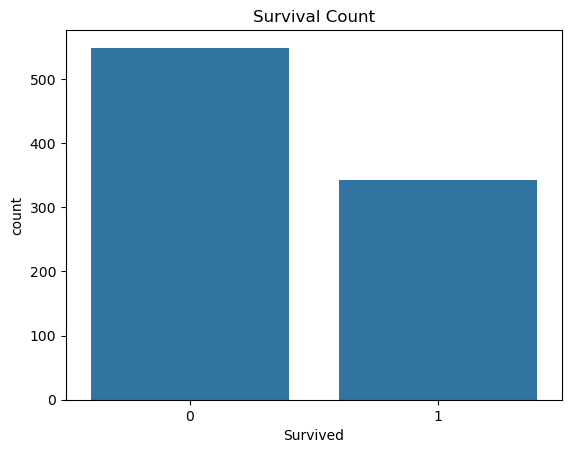

In [17]:
#passengers survived vs did not survive
sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.show()

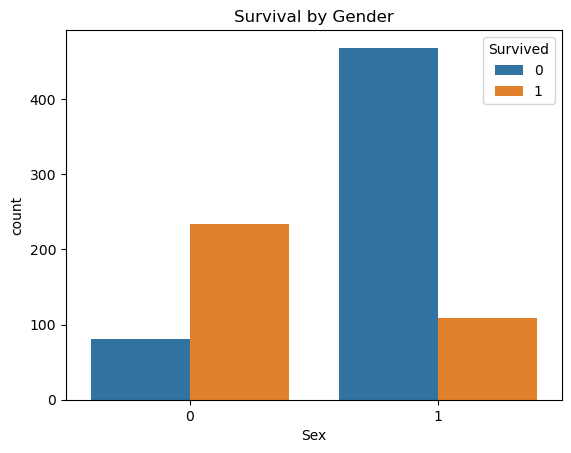

In [18]:
#survival female vs male
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Survival by Gender")
plt.show()

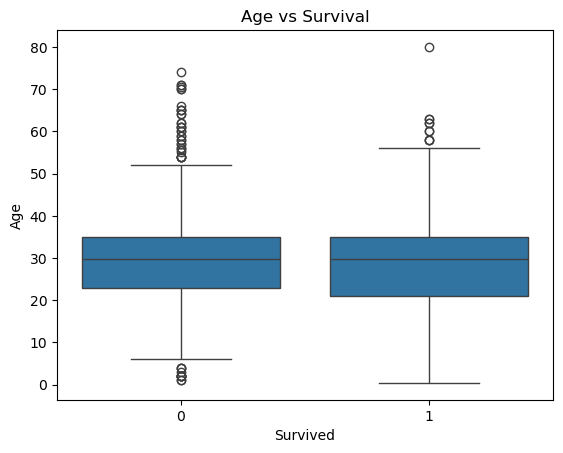

In [21]:
#survival vs age
sns.boxplot(x='Survived', y='Age', data=data)
plt.title("Age vs Survival")
plt.show()

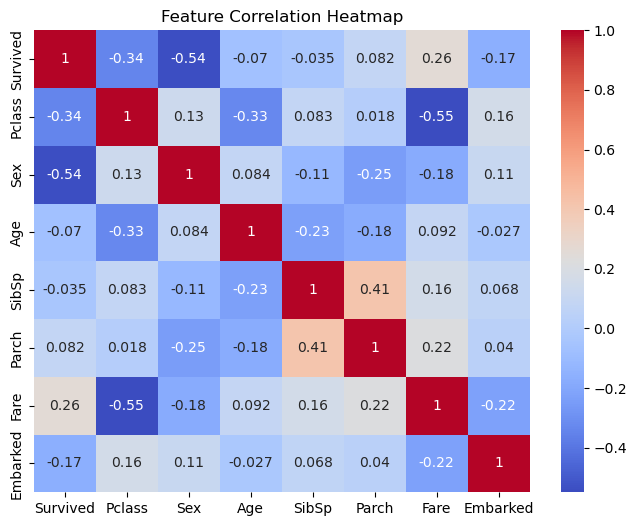

In [23]:
#corelation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
#Sex has strong correlation with survival.

## PREDICTION ##

In [16]:
sample = [[3,0,22,1,0,7.25,2]]
prediction = model.predict(sample)
print(prediction)

[1]


C:\Users\tanuu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
